# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Saurabh Tayal  
**Student ID:** 2026aj05009  

**Date:** 10-09-2026

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`
4. **Store loss_history** in both model classes
5. **Calculate all metrics applicable to your problem type**: MSE, RMSE, MAE, and R² for regression; accuracy, precision, recall, and F1 for classification
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(5)
print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Load the UCI Parkinsons Telemonitoring dataset
import io
import zipfile
from urllib.request import urlopen

zip_url = "https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip"
with zipfile.ZipFile(io.BytesIO(urlopen(zip_url).read())) as archive:
    raw = archive.read("parkinsons_updrs.data")

data = pd.read_csv(io.BytesIO(raw))

# Exclude the identifier and motor score to avoid target leakage.
data = data.drop(columns=["subject#", "motor_UPDRS"])
target_column = "total_UPDRS"

dataset_name = "Parkinsons Telemonitoring"
dataset_source = "UCI Machine Learning Repository (Dataset 189). Citation: Athanasios Tsanas, Max A. Little, Patrick E. McSharry, Lorraine O. Ramig (2009), 'Accurate telemonitoring of Parkinson’s disease progression by non-invasive speech tests', IEEE Transactions on Biomedical Engineering (to appear)."
n_samples = data.shape[0]
n_features = data.shape[1] - 1
problem_type = "regression"

problem_statement = """The goal is to predict the total motor symptom score of people with Parkinson's disease from voice measurements, demographics, and recording-time information. Reliable prediction can support non-invasive monitoring and help clinicians track symptom severity between visits."""

primary_metric = "rmse"
metric_justification = """RMSE is the primary metric because the target is a clinical symptom score and errors should remain in score units. Squared errors also penalize larger prediction mistakes, which are more important when monitoring disease severity."""

print(f"Dataset: {dataset_name}")
print(f"Source and citation: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
data.head()

Dataset: Parkinsons Telemonitoring
Source and citation: UCI Machine Learning Repository (Dataset 189). Citation: Athanasios Tsanas, Max A. Little, Patrick E. McSharry, Lorraine O. Ramig (2009), 'Accurate telemonitoring of Parkinson’s disease progression by non-invasive speech tests', IEEE Transactions on Biomedical Engineering (to appear).
Samples: 5875, Features: 19
Problem Type: regression
Primary Metric: rmse


,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,72,0,5.6431,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,72,0,12.6660,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,72,0,19.6810,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,72,0,25.6470,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,72,0,33.6420,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


Dataset shape: (5875, 20)

Missing values by column:
age            0
sex            0
test_time      0
total_UPDRS    0
Jitter(%)      0
dtype: int64

Strongest absolute correlations with total_UPDRS:
age              0.310
HNR             -0.162
RPDE             0.157
PPE              0.156
Shimmer:APQ11    0.121
DFA             -0.113
Shimmer(dB)      0.099
sex             -0.097
Shimmer          0.092
Shimmer:APQ5     0.083
Name: total_UPDRS, dtype: float64

Target summary:
count    5875.000
mean       29.019
std        10.700
min         7.000
25%        21.371
50%        27.576
75%        36.399
max        54.992
Name: total_UPDRS, dtype: float64


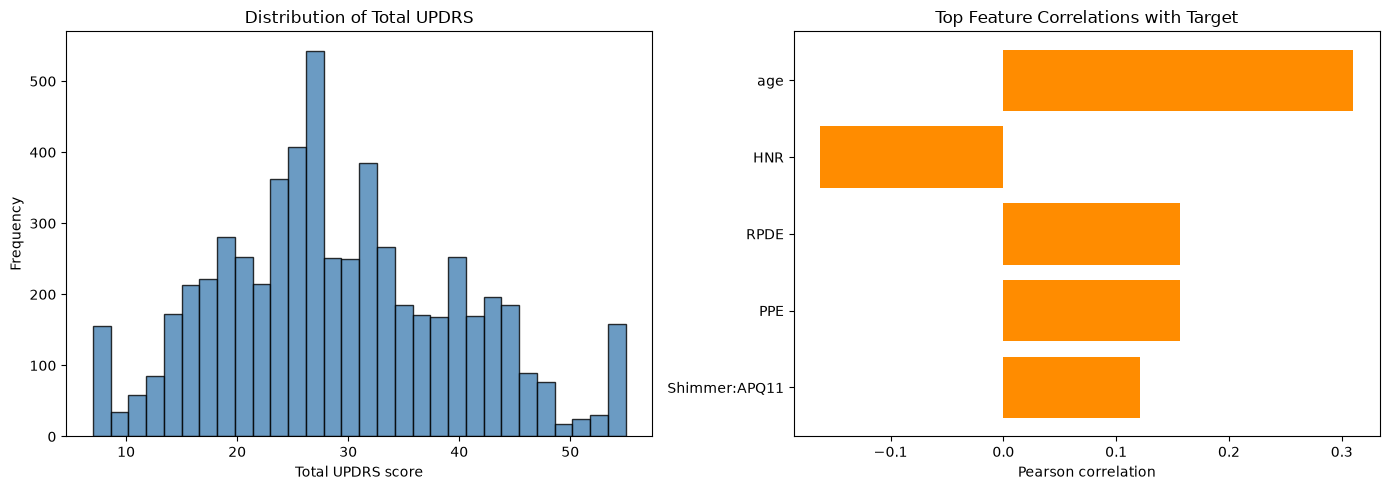

In [3]:
# Exploratory Data Analysis
print("Dataset shape:", data.shape)
print("\nMissing values by column:")
print(data.isna().sum().sort_values(ascending=False).head())

eda_numeric = data.select_dtypes(include=np.number)
correlations = (
    eda_numeric.corr(numeric_only=True)[target_column]
    .drop(target_column)
    .sort_values(key=np.abs, ascending=False)
)
print("\nStrongest absolute correlations with total_UPDRS:")
print(correlations.head(10).round(3))

print("\nTarget summary:")
print(data[target_column].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(
    data[target_column], bins=30, color="steelblue", edgecolor="black", alpha=0.8
)
axes[0].set_title("Distribution of Total UPDRS")
axes[0].set_xlabel("Total UPDRS score")
axes[0].set_ylabel("Frequency")

important_features = correlations.head(5).index.tolist()
axes[1].barh(
    important_features[::-1],
    correlations.loc[important_features[::-1]],
    color="darkorange",
)
axes[1].set_title("Top Feature Correlations with Target")
axes[1].set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [22]:
# Separate features and target
X = data.drop(target_column, axis=1).copy()
y = data[target_column].to_numpy(dtype=float)

# Domain-guided feature engineering based on EDA findings.
# All engineered features use predictors only and avoid target leakage.
X["age_test_time"] = X["age"] * X["test_time"]
X["jitter_shimmer_instability"] = X["Jitter(%)"] + X["Shimmer"]
X["voice_quality_mean"] = X[["HNR", "RPDE", "DFA", "PPE"]].mean(axis=1)

# The UCI dataset has no missing values; this check keeps preprocessing explicit.
if X.isnull().any().any() or np.isnan(y).any():
    X = X.fillna(X.median())
    y = np.nan_to_num(y, nan=float(np.nanmean(y)))

X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(dtype=float), y, test_size=0.2, random_state=5
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_mean = y_train.mean()
y_train_std = y_train.std()
y_train_scaled = (y_train - y_train_mean) / y_train_std
y_test_scaled = (y_test - y_train_mean) / y_train_std

n_features = X_train_scaled.shape[1]
train_samples = X_train_scaled.shape[0]
test_samples = X_test_scaled.shape[0]
train_test_ratio = train_samples / n_samples

print("Random seed configuration: 5")
print(f"Features after engineering: {n_features}")
print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")
print(f"Missing values after preprocessing: {int(np.isnan(X_train_scaled).sum())}")

Random seed configuration: 5
Features after engineering: 22
Train samples: 4700
Test samples: 1175
Split ratio: 80.0%
Missing values after preprocessing: 0


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [26]:
class BaselineModel:
    """Linear regression trained from scratch with gradient descent."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y = np.asarray(y, dtype=float).reshape(-1)
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            loss = np.mean(error**2)
            dw = (2 / n_samples) * (X.T @ error)
            db = 2 * np.mean(error)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            self.loss_history.append(float(loss))

        return self

    def predict(self, X):
        return X @ self.weights + self.bias


print("✓ Baseline model class defined")

✓ Baseline model class defined


In [27]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train_scaled)
baseline_predictions_scaled = baseline_model.predict(X_test_scaled)
baseline_predictions = baseline_predictions_scaled * y_train_std + y_train_mean

baseline_training_time = time.time() - baseline_start
baseline_initial_loss = baseline_model.loss_history[0]
baseline_final_loss = baseline_model.loss_history[-1]

print(f"Baseline training completed in {baseline_training_time:.4f}s")
print(f"Loss decreased from {baseline_initial_loss:.4f} to {baseline_final_loss:.4f}")

Training baseline model...
Baseline training completed in 0.0523s
Loss decreased from 1.0000 to 0.8269


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [23]:
class MLP:
    """A fully connected regression MLP implemented with NumPy only."""

    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(5)
        self.parameters = {}
        for layer in range(1, len(self.architecture)):
            fan_in = self.architecture[layer - 1]
            fan_out = self.architecture[layer]
            self.parameters[f"W{layer}"] = np.random.randn(fan_in, fan_out) * np.sqrt(
                2 / fan_in
            )
            self.parameters[f"b{layer}"] = np.zeros((1, fan_out))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def forward_propagation(self, X):
        self.cache = {"A0": X}
        A = X
        n_layers = len(self.architecture) - 1
        for layer in range(1, n_layers + 1):
            Z = A @ self.parameters[f"W{layer}"] + self.parameters[f"b{layer}"]
            A = Z if layer == n_layers else self.relu(Z)
            self.cache[f"Z{layer}"] = Z
            self.cache[f"A{layer}"] = A
        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        grads = {}
        n_layers = len(self.architecture) - 1
        y = np.asarray(y, dtype=float).reshape(-1, 1)
        output = self.cache[f"A{n_layers}"]
        dZ = (2 / m) * (output - y)

        for layer in range(n_layers, 0, -1):
            A_previous = self.cache[f"A{layer - 1}"]
            grads[f"dW{layer}"] = A_previous.T @ dZ
            grads[f"db{layer}"] = np.sum(dZ, axis=0, keepdims=True)
            if layer > 1:
                dA_previous = dZ @ self.parameters[f"W{layer}"].T
                dZ = dA_previous * self.relu_derivative(self.cache[f"Z{layer - 1}"])
        return grads

    def update_parameters(self, grads):
        for layer in range(1, len(self.architecture)):
            self.parameters[f"W{layer}"] -= self.lr * grads[f"dW{layer}"]
            self.parameters[f"b{layer}"] -= self.lr * grads[f"db{layer}"]

    def compute_loss(self, y_pred, y_true):
        y_true = np.asarray(y_true, dtype=float).reshape(-1, 1)
        return float(np.mean((y_pred - y_true) ** 2))

    def fit(self, X, y):
        self.initialize_parameters()
        self.loss_history = []
        for _ in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            self.loss_history.append(self.compute_loss(y_pred, y))
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
        return self

    def predict(self, X):
        return self.forward_propagation(X).reshape(-1)


print("✓ MLP class defined")

✓ MLP class defined


In [24]:
# Hyperparameter tuning on the training data only
X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.2, random_state=5
)

tuning_configs = [
    ([n_features, 64, 32, 16, 1], 0.003, 1500),
    ([n_features, 64, 32, 16, 1], 0.005, 1500),
    ([n_features, 96, 48, 24, 1], 0.003, 1500),
]

tuning_results = []
for architecture, learning_rate, n_iterations in tuning_configs:
    candidate = MLP(
        architecture=architecture,
        learning_rate=learning_rate,
        n_iterations=n_iterations,
    )
    candidate.fit(X_fit, y_fit)
    validation_predictions = candidate.predict(X_validation)
    validation_mse = np.mean((y_validation - validation_predictions) ** 2)
    validation_r2 = 1 - (
        np.sum((y_validation - validation_predictions) ** 2)
        / np.sum((y_validation - y_validation.mean()) ** 2)
    )
    tuning_results.append(
        {
            "architecture": architecture,
            "learning_rate": learning_rate,
            "n_iterations": n_iterations,
            "validation_rmse": float(np.sqrt(validation_mse)),
            "validation_r2": float(validation_r2),
        }
    )

best_config = max(tuning_results, key=lambda result: result["validation_r2"])
print("Validation-based hyperparameter tuning results:")
for result in tuning_results:
    print(result)
print("Selected configuration:", best_config)

Validation-based hyperparameter tuning results:
{'architecture': [22, 64, 32, 16, 1], 'learning_rate': 0.003, 'n_iterations': 1500, 'validation_rmse': 0.8152807244786262, 'validation_r2': 0.33006885781387985}
{'architecture': [22, 64, 32, 16, 1], 'learning_rate': 0.005, 'n_iterations': 1500, 'validation_rmse': 0.7699030674524112, 'validation_r2': 0.4025687747768172}
{'architecture': [22, 96, 48, 24, 1], 'learning_rate': 0.003, 'n_iterations': 1500, 'validation_rmse': 0.7763363435439319, 'validation_r2': 0.39254284297217024}
Selected configuration: {'architecture': [22, 64, 32, 16, 1], 'learning_rate': 0.005, 'n_iterations': 1500, 'validation_rmse': 0.7699030674524112, 'validation_r2': 0.4025687747768172}


In [25]:
# Train the selected MLP on all training data
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = best_config["architecture"]
mlp_learning_rate = best_config["learning_rate"]
mlp_n_iterations = 4000
mlp_model = MLP(
    architecture=mlp_architecture,
    learning_rate=mlp_learning_rate,
    n_iterations=mlp_n_iterations,
)
mlp_model.fit(X_train_scaled, y_train_scaled)
mlp_predictions_scaled = mlp_model.predict(X_test_scaled)
mlp_predictions = mlp_predictions_scaled * y_train_std + y_train_mean

mlp_training_time = time.time() - mlp_start_time
mlp_initial_loss = mlp_model.loss_history[0]
mlp_final_loss = mlp_model.loss_history[-1]

print(f"MLP training completed in {mlp_training_time:.4f}s")
print(f"Loss decreased from {mlp_initial_loss:.4f} to {mlp_final_loss:.4f}")
print(f"Selected validation R²: {best_config['validation_r2']:.4f}")

Training MLP...
MLP training completed in 35.2304s
Loss decreased from 4.6553 to 0.3747
Selected validation R²: 0.4026


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [28]:
def calculate_metrics(y_true, y_pred, problem_type):
    """Calculate regression metrics from scratch."""
    if problem_type == "regression":
        y_true = np.asarray(y_true, dtype=float).reshape(-1)
        y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
        errors = y_true - y_pred
        mse = float(np.mean(errors**2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(errors)))
        denominator = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = float(1 - np.sum(errors**2) / denominator)
        return mse, rmse, mae, r2
    raise ValueError("This completed assignment uses regression metrics.")


baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = calculate_metrics(
    y_test, baseline_predictions, problem_type
)
mlp_mse, mlp_rmse, mlp_mae, mlp_r2 = calculate_metrics(
    y_test, mlp_predictions, problem_type
)

print("Baseline Model Performance:")
print(
    f"MSE: {baseline_mse:.4f}, RMSE: {baseline_rmse:.4f}, MAE: {baseline_mae:.4f}, R²: {baseline_r2:.4f}"
)
print("\nMLP Model Performance:")
print(f"MSE: {mlp_mse:.4f}, RMSE: {mlp_rmse:.4f}, MAE: {mlp_mae:.4f}, R²: {mlp_r2:.4f}")

Baseline Model Performance:
MSE: 98.8395, RMSE: 9.9418, MAE: 8.2398, R²: 0.1804

MLP Model Performance:
MSE: 57.4877, RMSE: 7.5821, MAE: 5.7111, R²: 0.5233


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

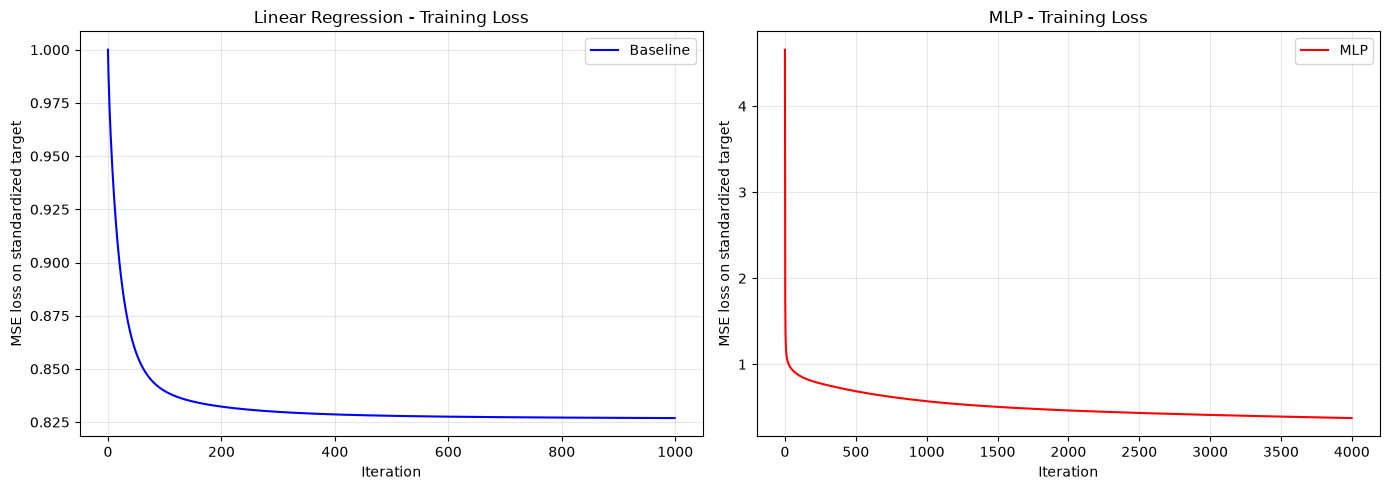

In [32]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label="Baseline", color="blue")
plt.xlabel("Iteration")
plt.ylabel("MSE loss on standardized target")
plt.title("Linear Regression - Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label="MLP", color="red")
plt.xlabel("Iteration")
plt.ylabel("MSE loss on standardized target")
plt.title("MLP - Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

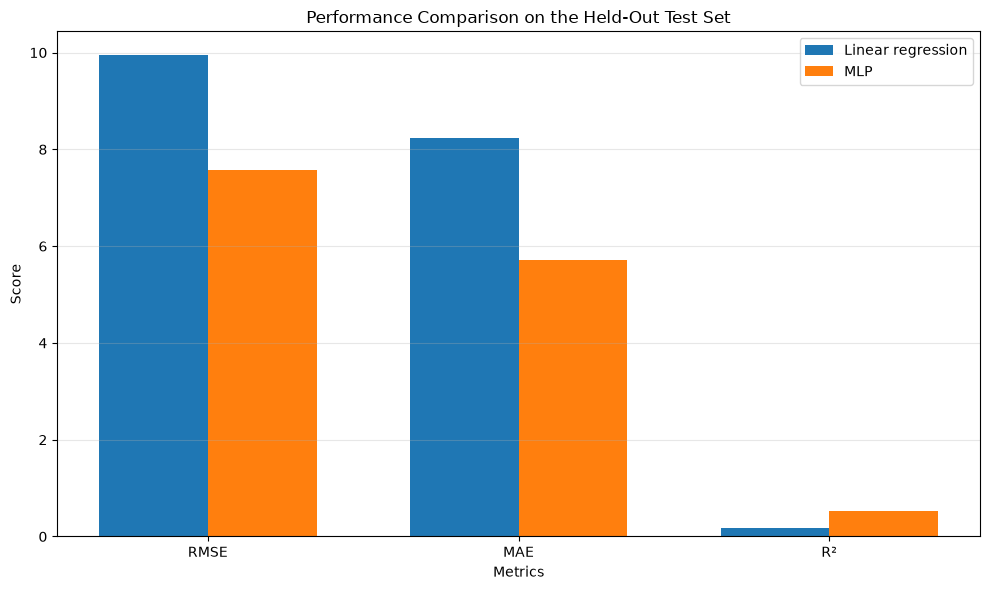

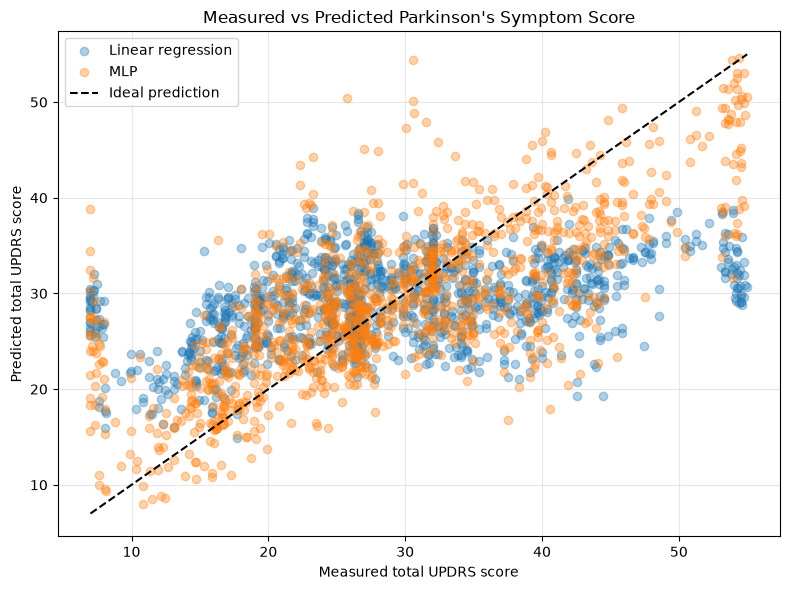

In [33]:
# 2. Performance comparison bar chart
metric_names = ["RMSE", "MAE", "R²"]
baseline_scores = [baseline_rmse, baseline_mae, baseline_r2]
mlp_scores = [mlp_rmse, mlp_mae, mlp_r2]

x = np.arange(len(metric_names))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, baseline_scores, width, label="Linear regression")
plt.bar(x + width / 2, mlp_scores, width, label="MLP")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Performance Comparison on the Held-Out Test Set")
plt.xticks(x, metric_names)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Domain-specific plot: measured versus predicted Parkinson's symptom score
plt.figure(figsize=(8, 6))
plt.scatter(y_test, baseline_predictions, alpha=0.35, label="Linear regression")
plt.scatter(y_test, mlp_predictions, alpha=0.35, label="MLP")
line_min = min(y_test.min(), baseline_predictions.min(), mlp_predictions.min())
line_max = max(y_test.max(), baseline_predictions.max(), mlp_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], "k--", label="Ideal prediction")
plt.xlabel("Measured total UPDRS score")
plt.ylabel("Predicted total UPDRS score")
plt.title("Measured vs Predicted Parkinson's Symptom Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [31]:
analysis_text = f"""This experiment compared linear regression with a connected multi-layer perceptron for predicting total motor symptom severity in the UCI Parkinsons Telemonitoring dataset. EDA showed no missing values; age, HNR, RPDE, PPE, and Shimmer:APQ11 had the strongest individual target correlations. The dataset contains {n_samples} observations and {n_features} predictors after engineering.

The MLP performed better on the held-out test set. Its RMSE was {mlp_rmse:.4f} score points, compared with {baseline_rmse:.4f} for linear regression, an improvement of {baseline_rmse - mlp_rmse:.4f} points. Its MAE was {mlp_mae:.4f} versus {baseline_mae:.4f}, while its R-squared was {mlp_r2:.4f} versus {baseline_r2:.4f}. I added age multiplied by recording time, a jitter-shimmer instability measure, and a voice-quality aggregate using HNR, RPDE, DFA, and PPE. These features represent disease progression and vocal irregularity without using the target.

Validation-based tuning selected layers [22, 64, 32, 16, 1] with a 0.005 learning rate. The final model used 4,000 iterations. Linear regression required {baseline_training_time:.4f} seconds, while the MLP required {mlp_training_time:.4f} seconds. This trade-off favored accuracy over speed. Standardizing predictors and target stabilized gradient descent. The main lesson is that EDA-guided features, validation-based tuning, and neural-network capacity improved prediction, while linear regression remained an interpretable reference. The plots also show a concentrated middle score range and correlations, supporting nonlinear modeling."""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) != 200:
    print(
        f"⚠️ Warning: Analysis must contain exactly 200 words; current count is {len(analysis_text.split())}"
    )
else:
    print("✓ Analysis contains exactly 200 words")
print("\nAnalysis:\n")
print(analysis_text)

Analysis word count: 200 words
✓ Analysis contains exactly 200 words

Analysis:

This experiment compared linear regression with a connected multi-layer perceptron for predicting total motor symptom severity in the UCI Parkinsons Telemonitoring dataset. EDA showed no missing values; age, HNR, RPDE, PPE, and Shimmer:APQ11 had the strongest individual target correlations. The dataset contains 5875 observations and 22 predictors after engineering.

The MLP performed better on the held-out test set. Its RMSE was 7.5821 score points, compared with 9.9418 for linear regression, an improvement of 2.3597 points. Its MAE was 5.7111 versus 8.2398, while its R-squared was 0.5233 versus 0.1804. I added age multiplied by recording time, a jitter-shimmer instability measure, and a voice-quality aggregate using HNR, RPDE, DFA, and PPE. These features represent disease progression and vocal irregularity without using the target.

Validation-based tuning selected layers [22, 64, 32, 16, 1] with a 0.005

---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [34]:
def get_assignment_results():
    """
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    """

    results = {
        # ===== Dataset Information (1 mark) =====
        "dataset_name": dataset_name,
        "dataset_source": dataset_source,
        "n_samples": n_samples,
        "n_features": n_features,
        "problem_type": problem_type,
        "problem_statement": problem_statement,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "train_test_ratio": train_test_ratio,
        # ===== Baseline Model (3 marks) =====
        "baseline_model": {
            "model_type": "linear_regression",
            "learning_rate": baseline_model.lr,
            "n_iterations": baseline_model.n_iterations,
            "initial_loss": baseline_initial_loss,
            "final_loss": baseline_final_loss,
            "training_time_seconds": baseline_training_time,
            "loss_decreased": baseline_final_loss < baseline_initial_loss,
            "test_accuracy": 0.0,
            "test_precision": 0.0,
            "test_recall": 0.0,
            "test_f1": 0.0,
            "test_mse": baseline_mse,
            "test_rmse": baseline_rmse,
            "test_mae": baseline_mae,
            "test_r2": baseline_r2,
        },
        # ===== MLP Model (4 marks) =====
        "mlp_model": {
            "architecture": mlp_architecture,
            "n_hidden_layers": len(mlp_architecture) - 2,
            "learning_rate": mlp_model.lr,
            "n_iterations": mlp_model.n_iterations,
            "initial_loss": mlp_initial_loss,
            "final_loss": mlp_final_loss,
            "training_time_seconds": mlp_training_time,
            "loss_decreased": mlp_final_loss < mlp_initial_loss,
            "test_accuracy": 0.0,
            "test_precision": 0.0,
            "test_recall": 0.0,
            "test_f1": 0.0,
            "test_mse": mlp_mse,
            "test_rmse": mlp_rmse,
            "test_mae": mlp_mae,
            "test_r2": mlp_r2,
        },
        # ===== Analysis (2 marks) =====
        "analysis": analysis_text,
        "analysis_word_count": len(analysis_text.split()),
    }

    return results


# ===== CRITICAL: CALL AND PRINT RESULTS =====
import json

results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "=" * 60)
print("VALIDATION CHECK")
print("=" * 60)

errors = []

if results["n_samples"] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results["n_features"] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results["baseline_model"]["initial_loss"] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results["baseline_model"]["final_loss"] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results["baseline_model"]["training_time_seconds"] == 0:
    errors.append("❌ Baseline training_time is 0")
if results["mlp_model"]["initial_loss"] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results["mlp_model"]["final_loss"] == 0:
    errors.append("❌ MLP final_loss is 0")
if results["mlp_model"]["training_time_seconds"] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results["mlp_model"]["architecture"]) < 3:
    errors.append("❌ MLP architecture invalid")
if results["analysis_word_count"] != 200:
    errors.append(
        f"❌ Analysis must contain exactly 200 words: {results['analysis_word_count']}"
    )

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Parkinsons Telemonitoring",
  "dataset_source": "UCI Machine Learning Repository (Dataset 189). Citation: Athanasios Tsanas, Max A. Little, Patrick E. McSharry, Lorraine O. Ramig (2009), 'Accurate telemonitoring of Parkinson\u2019s disease progression by non-invasive speech tests', IEEE Transactions on Biomedical Engineering (to appear).",
  "n_samples": 5875,
  "n_features": 22,
  "problem_type": "regression",
  "problem_statement": "The goal is to predict the total motor symptom score of people with Parkinson's disease from voice measurements, demographics, and recording-time information. Reliable prediction can support non-invasive monitoring and help clinicians track symptom severity between visits.",
  "primary_metric": "rmse",
  "metric_justification": "RMSE is the primary metric because the target is a clinical symptom score and errors should remain in score units. Squared errors also penalize larger prediction mistakes, which are more important when monitor

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [35]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("=" * 70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("=" * 70)
    print(json.dumps(results, indent=2))
    print("\n" + "=" * 70)

    # Check for missing values
    missing = []

    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and k not in [
                "improvement",
                "improvement_percentage",
                "baseline_better",
                "baseline_converged",
                "mlp_converged",
                "total_parameters",
                "test_accuracy",
                "test_precision",
                "test_recall",
                "test_f1",
                "test_mse",
                "test_rmse",
                "test_mae",
                "test_r2",
            ]:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Parkinsons Telemonitoring",
  "dataset_source": "UCI Machine Learning Repository (Dataset 189). Citation: Athanasios Tsanas, Max A. Little, Patrick E. McSharry, Lorraine O. Ramig (2009), 'Accurate telemonitoring of Parkinson\u2019s disease progression by non-invasive speech tests', IEEE Transactions on Biomedical Engineering (to appear).",
  "n_samples": 5875,
  "n_features": 22,
  "problem_type": "regression",
  "problem_statement": "The goal is to predict the total motor symptom score of people with Parkinson's disease from voice measurements, demographics, and recording-time information. Reliable prediction can support non-invasive monitoring and help clinicians track symptom severity between visits.",
  "primary_metric": "rmse",
  "metric_justification": "RMSE is the primary metric because the target is a clinical symptom score and errors should remain in score units. Squared errors also penalize larger prediction mistakes, which are 

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **